# 01 · Dataset acquisition & preprocessing
**Project:** Brain Tumor Detection Using Convolutional Neural Networks (ICT-4442)
**Shared by all members** — every model reads the split created here.

Pipeline:
1. **Download** the Brain Tumor MRI Dataset (Masoud Nickparvar, Kaggle).
2. **Clean** — open every file (drop unreadable ones) and hash it to find exact duplicates.
3. **Encode** — glioma + meningioma + pituitary → `tumor` (1); notumor → `no_tumor` (0).
4. **Split** — official *Testing* folder = held-out test set; official *Training* folder → stratified 80 / 20 train / validation (seed 42).
5. **Write** the merged folders `data/binary/{train,val,test}/{no_tumor,tumor}` that Keras `ImageDataGenerator.flow_from_directory` reads, and save the split manifest.

In [1]:
import os, sys
os.environ.setdefault("KERAS_BACKEND", "torch")   # Keras 3 backend used for our runs (CPU); "tensorflow" also works
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))        # make the project's src/ package importable

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from src import config, data_pipeline as dp, models, features, training

keras.utils.set_random_seed(config.SEED)
print("Keras", keras.__version__, "| backend:", keras.backend.backend())

Keras 3.15.1 | backend: torch


## 1. Download

In [2]:
raw_dir = dp.download_dataset()
print("raw dataset folder:", raw_dir.name)
counts = {(s, c.name): len(list(c.iterdir()))
          for s in ["Training", "Testing"] for c in sorted((raw_dir / s).iterdir())}
raw_counts = pd.Series(counts).unstack(0)[["Training", "Testing"]]
raw_counts.loc["total"] = raw_counts.sum()
raw_counts

raw dataset folder: 2


,Training,Testing
glioma,1400,400
meningioma,1400,400
notumor,1400,400
pituitary,1400,400
total,5600,1600


## 2. Scan and clean (readability, image sizes, duplicates)

In [3]:
df = dp.scan_images(raw_dir)
print("files scanned:", len(df), "| unreadable:", int((~df.readable).sum()))
print("colour modes:", df["mode"].value_counts().to_dict())
print("distinct image sizes:", df.groupby(["width", "height"]).ngroups)
df.groupby(["width", "height"]).size().sort_values(ascending=False).head(5).rename("files")

files scanned: 7200 | unreadable: 0
colour modes: {'RGB': 4129, 'L': 3067, 'RGBA': 3, 'P': 1}
distinct image sizes: 447


width  height
512    512       5014
225    225        338
630    630         90
201    251         57
228    221         51
Name: files, dtype: int64

In [4]:
df, dup_report = dp.mark_duplicates(df)
dup_report

{'duplicate_groups': 153,
 'files_removed': 187,
 'groups_crossing_train_test': 0,
 'groups_with_label_conflict': 0}

Exact duplicates (identical bytes) are removed, keeping one copy. None of them cross the
Training/Testing boundary and none have conflicting labels, so the official test set is not
contaminated. Removing them *before* the train/validation split also stops copies of the same
scan landing in both train and validation.

## 3–4. Binary encoding and train / validation / test split

In [5]:
split_df = dp.make_split(df)
pd.crosstab([split_df["split"], split_df["label"]], split_df["source_class"], margins=True)

source_class    glioma  meningioma  notumor  pituitary   All
split label                                                 
test  no_tumor       0           0      400          0   400
      tumor        386         398        0        400  1184
train no_tumor       0           0     1025          0  1025
      tumor       1120        1109        0       1089  3318
val   no_tumor       0           0      256          0   256
      tumor        280         277        0        273   830
All               1786        1784     1681       1762  7013

In [6]:
summary = dp.split_summary(split_df)
weights = dp.class_weights(split_df)
print("class weights from the TRAIN split (n_total / (2 * n_class)):",
      {config.CLASS_NAMES[k]: round(v, 3) for k, v in weights.items()})
summary

class weights from the TRAIN split (n_total / (2 * n_class)): {'no_tumor': 2.119, 'tumor': 0.654}


label,no_tumor,tumor,total,tumor_share_%
split,,,,
train,1025,3318,4343,76.4
val,256,830,1086,76.4
test,400,1184,1584,74.7


## 5. Write merged folders + split manifest

In [7]:
split_df = dp.write_binary_folders(split_df)
config.DATASET_INFO_DIR.mkdir(parents=True, exist_ok=True)
manifest = split_df.assign(original_file=split_df["path"].map(lambda p: "/".join(Path(p).parts[-3:])))
manifest[["binary_path", "split", "label", "source_class", "original_file", "md5", "width", "height"]] \
    .to_csv(config.SPLIT_MANIFEST, index=False)
summary.to_csv(config.DATASET_INFO_DIR / "split_summary.csv")
info = {
    "raw_files": int(len(df)),
    "unreadable_files": int((~df.readable).sum()),
    **dup_report,
    "images_used": int(len(split_df)),
    "split_counts": {s: int(n) for s, n in split_df["split"].value_counts().items()},
    "class_counts": {c: int(n) for c, n in split_df["label"].value_counts().items()},
    "class_weights": {config.CLASS_NAMES[k]: round(v, 4) for k, v in weights.items()},
}
(config.DATASET_INFO_DIR / "dataset_summary.json").write_text(json.dumps(info, indent=2))
info

{'raw_files': 7200,
 'unreadable_files': 0,
 'duplicate_groups': 153,
 'files_removed': 187,
 'groups_crossing_train_test': 0,
 'groups_with_label_conflict': 0,
 'images_used': 7013,
 'split_counts': {'train': 4343, 'test': 1584, 'val': 1086},
 'class_counts': {'tumor': 5332, 'no_tumor': 1681},
 'class_weights': {'no_tumor': 2.1185, 'tumor': 0.6545}}

## Figures

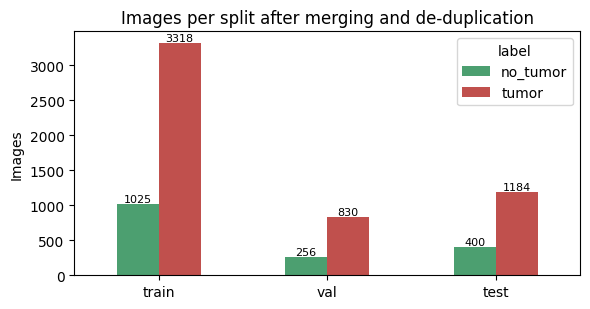

In [8]:
fig, ax = plt.subplots(figsize=(6, 3.2))
summary[["no_tumor", "tumor"]].plot.bar(ax=ax, color=["#4C9F70", "#C0504D"], rot=0)
for c in ax.containers:
    ax.bar_label(c, fontsize=8)
ax.set_ylabel("Images"); ax.set_xlabel(""); ax.set_title("Images per split after merging and de-duplication")
fig.tight_layout(); fig.savefig(config.FIG_DIR / "class_distribution.png", dpi=150); plt.show()

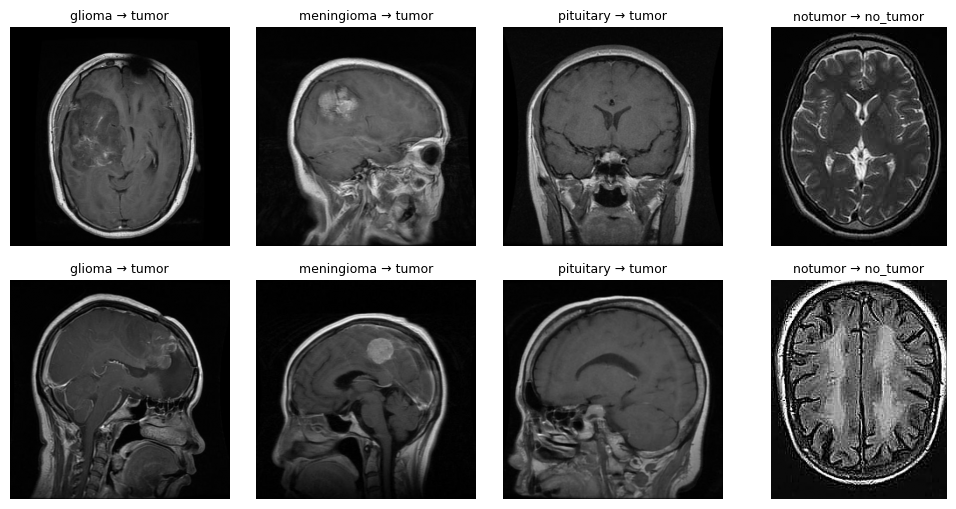

In [9]:
from PIL import Image
fig, axes = plt.subplots(2, 4, figsize=(10, 5.2))
for col, cls in enumerate(["glioma", "meningioma", "pituitary", "notumor"]):
    picks = split_df[(split_df.source_class == cls) & (split_df.split == "train")].sample(2, random_state=1)
    for row, p in enumerate(picks["path"]):
        axes[row, col].imshow(Image.open(p).convert("L"), cmap="gray")
        axes[row, col].set_title(f"{cls} → {'tumor' if cls != 'notumor' else 'no_tumor'}", fontsize=9)
        axes[row, col].axis("off")
fig.tight_layout(); fig.savefig(config.FIG_DIR / "sample_images.png", dpi=150); plt.show()

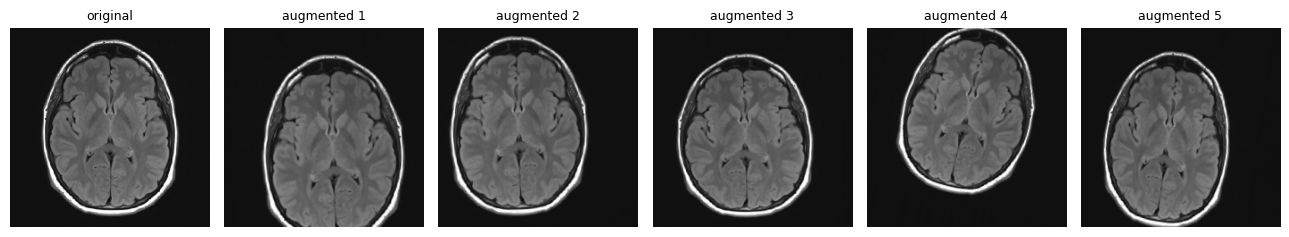

In [10]:
# training-only augmentation (used in the fine-tuning stage): rotation ±15°, shifts 10%, zoom 10%, horizontal flip
viewer = dp.ImageDataGenerator(**dp.AUGMENTATION)
img = keras.utils.img_to_array(keras.utils.load_img(
    config.ROOT / split_df[split_df.split == "train"]["binary_path"].iloc[0], target_size=config.CNN_IMG_SIZE))
fig, axes = plt.subplots(1, 6, figsize=(13, 2.5))
axes[0].imshow(img.astype("uint8")); axes[0].set_title("original", fontsize=9)
for i, ax in enumerate(axes[1:], start=1):
    ax.imshow(viewer.random_transform(img, seed=i).astype("uint8")); ax.set_title(f"augmented {i}", fontsize=9)
for ax in axes:
    ax.axis("off")
fig.tight_layout(); fig.savefig(config.FIG_DIR / "augmentation_examples.png", dpi=150); plt.show()

## Check the generators every model uses

In [11]:
vgg_pre = models.BACKBONES["vgg16"][1]
cnn_val = dp.make_cnn_generator("val", vgg_pre)
xb, yb = cnn_val[0]
print("CNN batch:", xb.shape, "labels one-hot:", yb.shape, "| class indices:", cnn_val.class_indices)
mlp_val = dp.make_mlp_generator("val")
xb, yb = mlp_val[0]
print("MLP batch:", xb.shape, "pixel range:", float(xb.min()), "-", float(xb.max()))

Found 1086 images belonging to 2 classes.


CNN batch: (32, 224, 224, 3) labels one-hot: (32, 2) | class indices: {'no_tumor': 0, 'tumor': 1}
Found 1086 images belonging to 2 classes.


MLP batch: (32, 64, 64, 1) pixel range: 0.0 - 1.0
